In [2]:
import pandas as pd

In [3]:
#split images to low contrast (low light) and normal

In [4]:
labeled_journals = pd.read_csv('doaj_journal_list_urls_from_doaj_bing_v1.csv')

In [5]:
labeled_journals

,Unnamed: 0,Journal_Title_Normalized,added,Journal Title,ISSN,Remove_Date,Add_Date,Reason,Data Source,URL,reason_category
0,0,"#tear: revista de educação, ciência e tecnologia",True,"#Tear: Revista de Educação, Ciência e Tecnologia",2238-8079,1677-09-22,2015-07-20,Still in DOAJ index,DOAJ,https://periodicos.ifrs.edu.br/index.php/tear/...,interesting reason
1,1,(en)clave comahue,True,(En)clave Comahue,2545-6466,1677-09-22,2019-05-13,Still in DOAJ index,DOAJ,http://revele.uncoma.edu.ar/htdoc/revele/index...,interesting reason
2,2,(پژوهش حسابداری و حسابرسی (پیوسته,True,(پژوهش حسابداری و حسابرسی (پیوسته,2676-7554,1677-09-22,2020-05-25,Still in DOAJ index,DOAJ,https://ijar.alzahra.ac.ir/,interesting reason
3,3,100-cs,True,100-Cs,0719-5737,1677-09-22,2018-12-27,Still in DOAJ index,DOAJ,http://100cs.cl/,interesting reason
4,4,1616,True,1616,0210-7287,1677-09-22,2020-03-09,Still in DOAJ index,DOAJ,http://revistas.usal.es/index.php/1616_Anuario...,interesting reason
...,...,...,...,...,...,...,...,...,...,...,...
15397,15412,силовое и энергетическое оборудование: автоном...,False,Силовое и энергетическое оборудование: Автоном...,2618-8716,2020-11-19,1677-09-22,Website URLs have security issues,DOAJ,https://onlinebooks.library.upenn.edu/webbin/b...,interesting reason
15398,15413,українська біографістика,False,Українська біографістика,2520-2855,2021-02-11,1677-09-22,Journal not adhering to best practice,DOAJ,http://ub.nbuv.gov.ua/,interesting reason
15399,15414,экономика региона,False,Экономика региона,2072-6414,2021-03-01,1677-09-22,Journal not adhering to Best practice,DOAJ,https://economyofregion.ru/,interesting reason
15400,15415,اندیشه‌های نوین تربیتی,False,اندیشه‌های نوین تربیتی,2476-7654,2022-06-09,1677-09-22,Journal not adhering to Best practice,DOAJ,http://ensani.ir/fa/article/journal/65/%D8%A7%...,interesting reason


In [6]:
import config
from imutils import paths
import random
import shutil
import os

In [7]:
from os import listdir

In [8]:
listdir(config.ORIG_INPUT_DATASET)

['in_DOAJ', 'out_DOAJ']

In [9]:
# grab the paths to all input images in the original input directory
# and shuffle them
imagePaths = list(paths.list_images(config.ORIG_INPUT_DATASET))
random.seed(42)
random.shuffle(imagePaths)

# compute the training and testing split
i = int(len(imagePaths) * config.TRAIN_SPLIT)
trainPaths = imagePaths[:i]
testPaths = imagePaths[i:]

# we'll be using part of the training data for validation
i = int(len(trainPaths) * config.VAL_SPLIT)
valPaths = trainPaths[:i]
trainPaths = trainPaths[i:]

# define the datasets that we'll be building
datasets = [
	("training", trainPaths, config.TRAIN_PATH),
	("validation", valPaths, config.VAL_PATH),
	("testing", testPaths, config.TEST_PATH)
]

In [10]:
import cv2
import numpy as np

In [11]:
def remove_extra_white(img_path):
    img = cv2.imread(img_path)
    ## (1) Convert to gray, and threshold
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    th, threshed = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)

    ## (2) Morph-op to remove noise
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11,11))
    morphed = cv2.morphologyEx(threshed, cv2.MORPH_CLOSE, kernel)

    ## (3) Find the max-area contour
    cnts = cv2.findContours(morphed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[-2]
    cnt = sorted(cnts, key=cv2.contourArea)[-1]

    ## (4) Crop and save it
    x,y,w,h = cv2.boundingRect(cnt)
    dst = img[y:y+h, x:x+w]
    cv2.imwrite(img_path, dst)
    

In [ ]:
# loop over the datasets
for (dType, imagePaths, baseOutput) in datasets:
    # show which data split we are creating
    print("[INFO] building '{}' split".format(dType))

    # if the output base output directory does not exist, create it
    if not os.path.exists(baseOutput):
        print("[INFO] 'creating {}' directory".format(baseOutput))
        os.makedirs(baseOutput)

    # loop over the input image paths
    for inputPath in imagePaths:
		# extract the filename of the input image along with its
		# corresponding class label
        filename = inputPath.split(os.path.sep)[-1]
        
        if filename[:-4] not in labeled_journals['ISSN'].tolist():
            continue
        
        label = inputPath.split(os.path.sep)[-2]

		# build the path to the label directory
        labelPath = os.path.sep.join([baseOutput, label])

		# if the label output directory does not exist, create it
        if not os.path.exists(labelPath):
            print("[INFO] 'creating {}' directory".format(labelPath))
            os.makedirs(labelPath)

		# construct the path to the destination image and then copy
		# the image itself
        p = os.path.sep.join([labelPath, filename])
        #remove white background in screenshots
        try:
            remove_extra_white(inputPath)
        except:
            continue
        shutil.copy2(inputPath, p)

[INFO] building 'training' split
[INFO] 'creating E:\SU_Backup\Predatory_Journal\release\screenshot_training\\training\in_DOAJ' directory
[INFO] 'creating E:\SU_Backup\Predatory_Journal\release\screenshot_training\\training\out_DOAJ' directory


In [13]:
labeled_journals['ISSN']

0        2238-8079
1        2545-6466
2        2676-7554
3        0719-5737
4        0210-7287
           ...    
15397    2618-8716
15398    2520-2855
15399    2072-6414
15400    2476-7654
15401    2676-3354
Name: ISSN, Length: 15402, dtype: object

In [17]:
filename[:-4]

'2597-9035'

In [1]:
import tensorflow as tf

2022-07-14 22:03:02.886658: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0


In [14]:
# import the necessary packages
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
import numpy as np
import pickle
import random
import os
import pickle

In [2]:
import config

In [3]:
IMG_SIZE = (224, 224)

In [4]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory('/home/hzhuang/Projects/Predatory_Journal/release/screenshot_for_training/training/',
                                                            shuffle=True,
                                                            batch_size=32,
                                                            image_size=IMG_SIZE)

Found 9499 files belonging to 2 classes.


2022-07-14 22:03:06.492939: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcuda.so.1
2022-07-14 22:03:06.520538: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-07-14 22:03:06.520655: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 0 with properties: 
pciBusID: 0000:01:00.0 name: NVIDIA GeForce GTX 1080 computeCapability: 6.1
coreClock: 1.7335GHz coreCount: 20 deviceMemorySize: 7.92GiB deviceMemoryBandwidth: 298.32GiB/s
2022-07-14 22:03:06.520673: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0
2022-07-14 22:03:06.526830: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublas.so.11
2022-07-14 22:03:06.526857: I tensorflow/stream_executor/pl

In [5]:
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory('/home/hzhuang/Projects/Predatory_Journal/release/screenshot_for_training/validation/',
                                                                 shuffle=True,
                                                                 batch_size=32,
                                                                 image_size=IMG_SIZE)

Found 2376 files belonging to 2 classes.


In [6]:
test_dataset = tf.keras.preprocessing.image_dataset_from_directory('/home/hzhuang/Projects/Predatory_Journal/release/screenshot_for_training/test/',
                                                                 shuffle=True,
                                                                 batch_size=32,
                                                                 image_size=IMG_SIZE)

Found 2958 files belonging to 2 classes.


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

2022-07-14 22:03:11.413511: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)
2022-07-14 22:03:11.436625: I tensorflow/core/platform/profile_utils/cpu_utils.cc:114] CPU Frequency: 3600000000 Hz


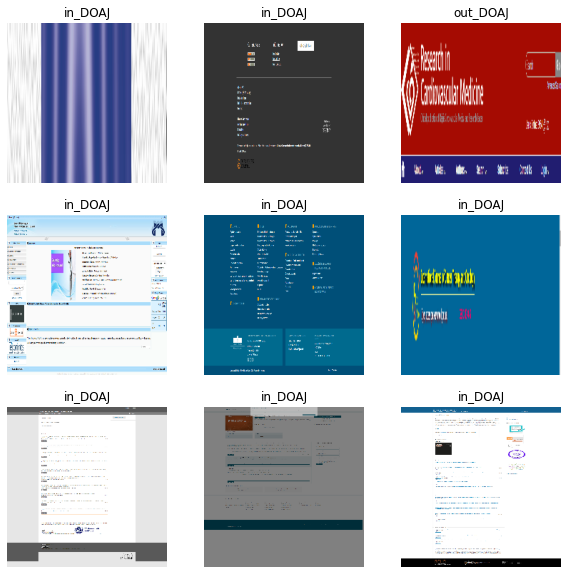

In [8]:
class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [10]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.experimental.preprocessing.RandomFlip('horizontal'),
  tf.keras.layers.experimental.preprocessing.RandomRotation(0.2),
])

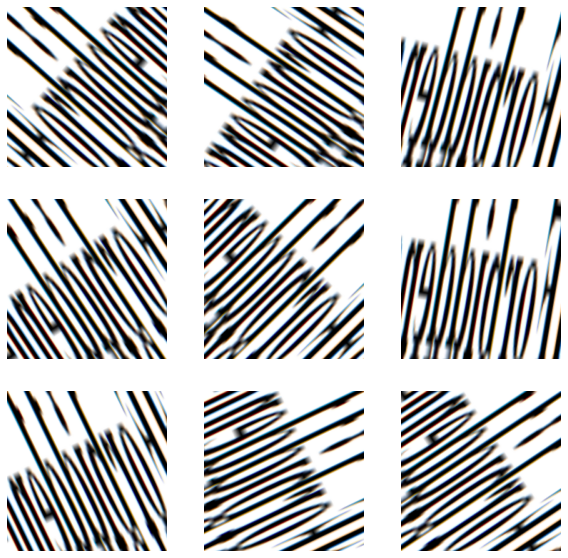

In [11]:
for image, _ in train_dataset.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

In [12]:
from tensorflow.keras import Input, Model

In [15]:
# load the ResNet50 network and initialize the label encoder
print("[INFO] loading network...")
model = ResNet50V2(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))
le = None

[INFO] loading network...


In [16]:
model.trainable = True

In [17]:
base_learning_rate = 0.0001

In [18]:
from tensorflow.keras.layers import AveragePooling2D, Flatten, Dense, Dropout

In [19]:
#headModel = model.output
#headModel = AveragePooling2D(pool_size=(7, 7))(headModel)
#headModel = Flatten(name="flatten")(headModel)
#headModel = Dense(256, activation="relu")(headModel)
#headModel = Dropout(0.5)(headModel)

In [20]:
#finalmodel = Model(inputs=model.input, outputs=headModel)

In [21]:
from tensorflow.keras.optimizers import Adam

In [22]:
#opt = Adam(lr=config.INIT_LR, decay=config.INIT_LR / config.NUM_EPOCHS)
#finalmodel.compile(loss="binary_crossentropy", optimizer=opt,
#	metrics=["accuracy"])

In [23]:
tf.config.run_functions_eagerly(True)

In [24]:
preprocess_input = tf.keras.applications.resnet_v2.preprocess_input

In [25]:
#inputs = tf.keras.Input(shape=(224, 224, 3))
#x = data_augmentation(inputs)
#x = preprocess_input(x)

In [26]:
prediction_layer = tf.keras.layers.Dense(1)

In [27]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()

In [28]:
tf.config.run_functions_eagerly(True)

In [29]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(inputs)
x = model(x, training=True)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

In [30]:
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [31]:
epochs =  3

history_fine = model.fit(train_dataset,
                         epochs=epochs,
                         validation_data=validation_dataset)

Epoch 1/3


2022-07-14 22:04:18.213407: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudnn.so.8
2022-07-14 22:04:18.407448: I tensorflow/stream_executor/cuda/cuda_dnn.cc:359] Loaded cuDNN version 8201
2022-07-14 22:04:18.602625: W tensorflow/stream_executor/gpu/asm_compiler.cc:99] *** WARNING *** You are using ptxas 9.1.108, which is older than 9.2.88. ptxas 9.x before 9.2.88 is known to miscompile XLA code, leading to incorrect results or invalid-address errors.

You do not need to update to CUDA 9.2.88; cherry-picking the ptxas binary is sufficient.
2022-07-14 22:04:18.637611: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublas.so.11
2022-07-14 22:04:18.818360: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublasLt.so.11


297/297 [==============================] - 103s 334ms/step - loss: 0.4326 - accuracy: 0.8375 - val_loss: 0.3798 - val_accuracy: 0.8586
Epoch 2/3
297/297 [==============================] - 101s 333ms/step - loss: 0.3426 - accuracy: 0.8578 - val_loss: 0.4034 - val_accuracy: 0.8573
Epoch 3/3
297/297 [==============================] - 101s 333ms/step - loss: 0.2695 - accuracy: 0.8886 - val_loss: 0.4281 - val_accuracy: 0.8556


In [1]:
loss, accuracy = model.evaluate(test_dataset,metrics)
print('Test accuracy :', accuracy)

NameError: name 'model' is not defined

In [33]:
from sklearn.metrics import classification_report

In [33]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score

In [34]:
mypredictions = np.array([])
labels =  np.array([])
for image_batch, y in test_dataset.as_numpy_iterator():
    predictions = model.predict_on_batch(image_batch).flatten()

    #apply a sigmoid since our model returns logits
    predictions = tf.nn.sigmoid(predictions)
    mypredictions = np.concatenate([mypredictions, predictions])
    labels = np.concatenate([labels, y])

In [35]:
roc_auc_score(labels, mypredictions)

0.7207474675373315

In [36]:
average_precision_score(labels, mypredictions)

0.4029524645197229

In [37]:
model.save('qj_classifier')

2022-04-24 21:18:05.344668: W tensorflow/python/util/util.cc:348] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.
/home/hzhuang/anaconda3/lib/python3.9/site-packages/tensorflow/python/keras/utils/generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '


INFO:tensorflow:Assets written to: low_contrast_classifier/assets


In [37]:
mypredictions = np.array([])
labels =  np.array([])
for image_batch, y in test_dataset.as_numpy_iterator():
    predictions = model.predict_on_batch(image_batch).flatten()

    #apply a sigmoid since our model returns logits
    predictions = tf.nn.sigmoid(predictions)
    predictions = tf.where(predictions < 0.5, 0, 1)
    mypredictions = np.concatenate([mypredictions, predictions])
    labels = np.concatenate([labels, y])

2022-07-07 15:59:36.680798: W tensorflow/core/framework/cpu_allocator_impl.cc:80] Allocation of 374544000 exceeds 10% of free system memory.


In [38]:
print(classification_report(mypredictions, labels))

              precision    recall  f1-score   support

         0.0       0.95      0.88      0.91      2700
         1.0       0.27      0.47      0.34       258

    accuracy                           0.84      2958
   macro avg       0.61      0.68      0.63      2958
weighted avg       0.89      0.84      0.86      2958



In [35]:
#without data augumentation
#print(classification_report(mypredictions, labels))

              precision    recall  f1-score   support

         0.0       0.94      0.88      0.91      2700
         1.0       0.26      0.45      0.33       258

    accuracy                           0.84      2958
   macro avg       0.60      0.66      0.62      2958
weighted avg       0.88      0.84      0.86      2958



In [38]:
predictions = model.predict(test_dataset)
# Apply a sigmoid since our model returns logits
predictions = tf.nn.sigmoid(predictions)
predictions = tf.where(predictions < 0.5, 0, 1)

print('Predictions:\n', predictions.numpy())
y_all = []
for x,y in test_dataset:
    print(y)
    y_all.extend(list(y.numpy()))

2022-04-24 21:18:39.572191: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:177] Filling up shuffle buffer (this may take a while): 130 of 256
2022-04-24 21:18:48.338593: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:230] Shuffle buffer filled.


Predictions:
 [[1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 

In [61]:
image_batch, y = test_dataset.as_numpy_iterator().next()

In [63]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0], dtype=int32)

In [70]:
len(labels)

2958

In [34]:
#from tensorflow.keras.preprocessing.image import load_img
#from tensorflow.keras.preprocessing.image import img_to_array

In [35]:
#img_to_array(load_img('test2.png'))

In [36]:
#model.predict(img_to_array(inputs(load_img('test2.png'))))

In [37]:
#test_dataset = tf.keras.preprocessing.image_dataset_from_directory('/home/hzhuang/Projects/ERA/test_classification',
#                                                                 shuffle=True,
#                                                                 batch_size=32,
#                                                                 image_size=IMG_SIZE)

In [47]:
test_dataset.file_path()

AttributeError: 'PrefetchDataset' object has no attribute 'file_path'

Predictions:
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0]
Labels:
 [0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 1 0 1]


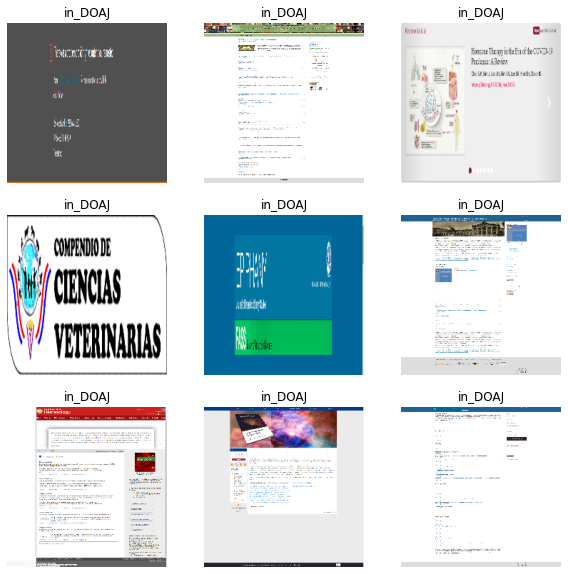

In [44]:
# Retrieve a batch of images from the test set
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch).flatten()

# Apply a sigmoid since our model returns logits
predictions = tf.nn.sigmoid(predictions)
predictions = tf.where(predictions < 0.5, 0, 1)

print('Predictions:\n', predictions.numpy())
print('Labels:\n', label_batch)

plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  plt.title(class_names[predictions[i]])
  plt.axis("off")

In [1]:
import tensorflow as tf

2022-04-14 13:01:28.026336: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0


In [2]:
tf.config.list_physical_devices()


2022-04-14 13:01:29.549967: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcuda.so.1
2022-04-14 13:01:29.596139: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-04-14 13:01:29.596273: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 0 with properties: 
pciBusID: 0000:01:00.0 name: NVIDIA GeForce GTX 1080 computeCapability: 6.1
coreClock: 1.7335GHz coreCount: 20 deviceMemorySize: 7.92GiB deviceMemoryBandwidth: 298.32GiB/s
2022-04-14 13:01:29.596293: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0
2022-04-14 13:01:29.598937: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublas.so.11
2022-04-14 13:01:29.598965: I tensorflow/stream_executor/pl

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
tf.test.is_gpu_available()

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


2022-04-14 13:01:33.835761: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-04-14 13:01:33.836436: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-04-14 13:01:33.836540: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 0 with properties: 
pciBusID: 0000:01:00.0 name: NVIDIA GeForce GTX 1080 computeCapability: 6.1
coreClock: 1.7335GHz coreCount: 20 deviceMemorySize: 7.92GiB deviceMemoryBandwidth: 298.32GiB/s
2022-04-14 13:01:33.836595: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1)

True

01:34.140660: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-04-14 13:01:34.140745: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1418] Created TensorFlow device (/device:GPU:0 with 6866 MB memory) -> physical GPU (device: 0, name: NVIDIA GeForce GTX 1080, pci bus id: 0000:01:00.0, compute capability: 6.1)
